# **🏨 Hotel Reservation Cancellation Prediction**

# **⬇️ Install & Import Libraries**

In [14]:
import warnings
warnings.filterwarnings('ignore')
import time

import shap
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, AdaBoostClassifier
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.combine import SMOTETomek
from sklearn.model_selection import cross_val_score


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = {
    'primary'  : '#1a3a5c',
    'secondary': '#e63946',
    'accent'   : '#f4a261',
    'green'    : '#2a9d8f',
    'light'    : '#a8dadc',
}
CANCEL_COLOR    = PALETTE['secondary']
NO_CANCEL_COLOR = PALETTE['green']
plt.style.use('seaborn-v0_8-white')

print('✅ All libraries imported successfully.')


✅ All libraries imported successfully.


#**📂 Load Dataset**

In [15]:
df = pd.read_csv('/content/Hotel Reservations.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['booking_status'].value_counts())
df.head(3)


Shape: (36275, 19)
Columns: ['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']

=== Data Types ===
Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date    

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled


# **🔍 Exploratory Data Analysis (EDA)**

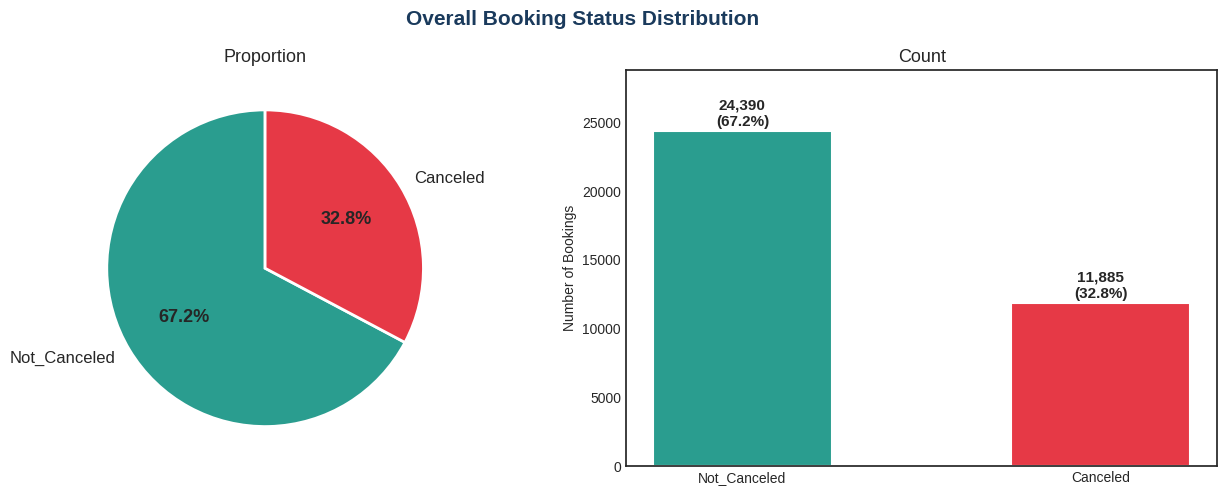

  Cancellation rate : 32.76%


In [47]:
%matplotlib inline
plt.close('all')
vc  = df['booking_status'].value_counts()
pct = df['booking_status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Overall Booking Status Distribution',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

colors_pie = [NO_CANCEL_COLOR, CANCEL_COLOR]
wedges, texts, autotexts = axes[0].pie(
    vc.values, labels=vc.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
axes[0].set_title('Proportion', fontsize=13)

bars = axes[1].bar(vc.index, vc.values, color=colors_pie,
                    width=0.5, edgecolor='white', linewidth=1.5)
for bar, count, p in zip(bars, vc.values, pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{count:,}\n({p:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Count', fontsize=13)
axes[1].set_ylabel('Number of Bookings')
axes[1].set_ylim(0, vc.max() * 1.18)

plt.tight_layout()
plt.savefig('fig_01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Cancellation rate : {pct["Canceled"]:.2f}%')


# **📊 a. Monthly Booking Trend**

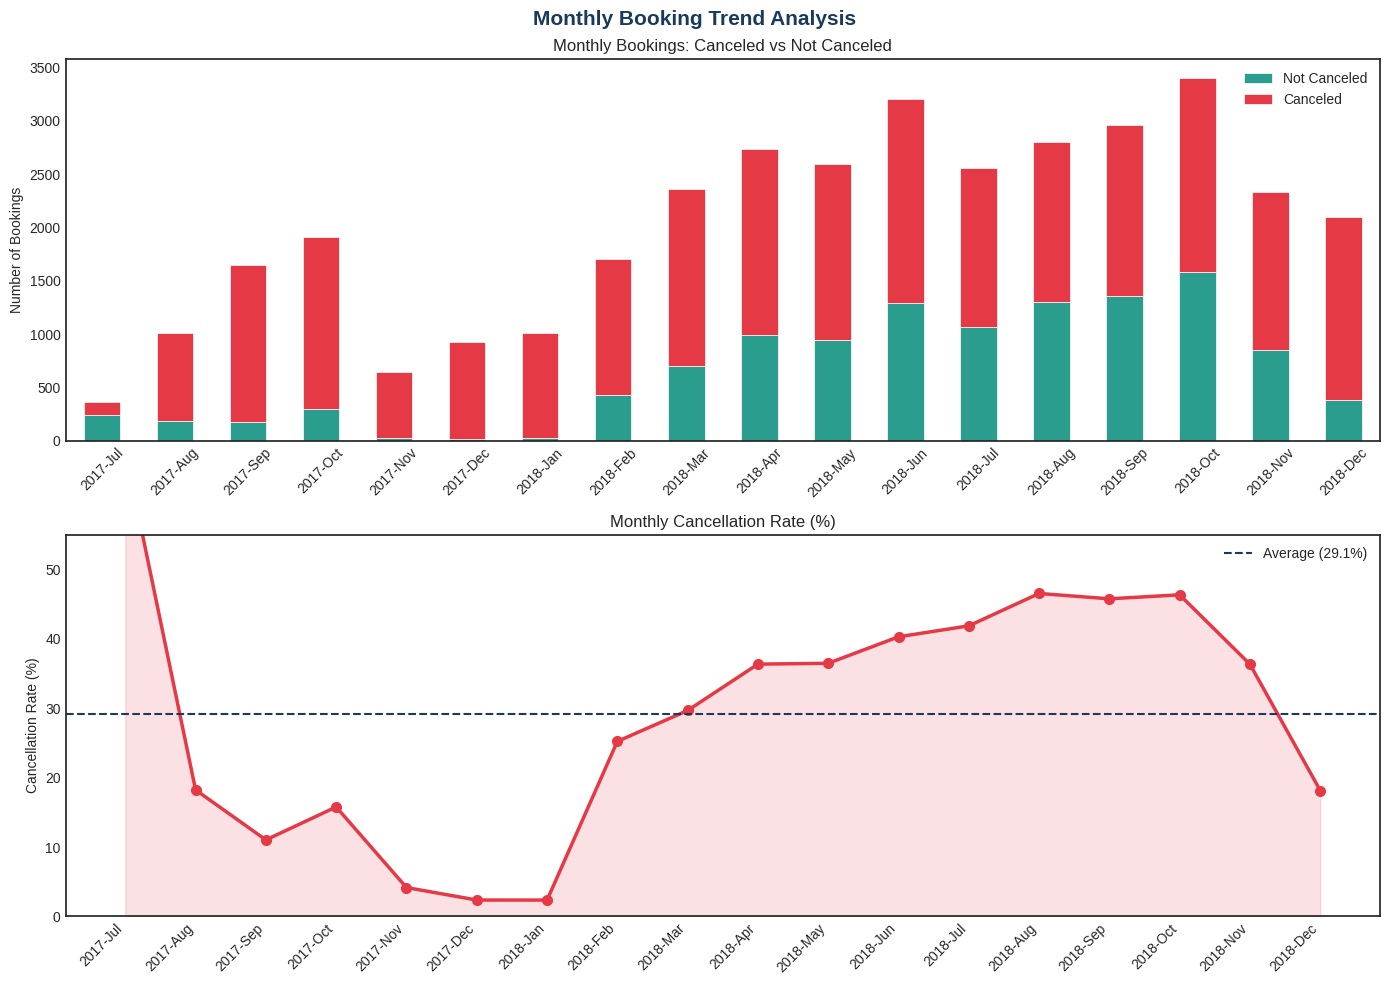

In [48]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = (df.groupby(['arrival_year','arrival_month','booking_status'])
           .size().unstack(fill_value=0))
monthly.index = [f'{y}-{month_names[m]}' for y, m in monthly.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly Booking Trend Analysis',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

monthly.plot(kind='bar', stacked=True, ax=axes[0],
             color=[NO_CANCEL_COLOR, CANCEL_COLOR], edgecolor='white', linewidth=0.5)
axes[0].set_title('Monthly Bookings: Canceled vs Not Canceled', fontsize=12)
axes[0].set_ylabel('Number of Bookings')
axes[0].legend(['Not Canceled','Canceled'])
axes[0].tick_params(axis='x', rotation=45)

cancel_rate = df.groupby(['arrival_year','arrival_month']).apply(
    lambda x: (x['booking_status'] == 'Canceled').mean() * 100, include_groups=False
)
cancel_rate.index = [f'{y}-{month_names[m]}' for y, m in cancel_rate.index]

axes[1].plot(cancel_rate.index, cancel_rate.values, color=CANCEL_COLOR,
             marker='o', linewidth=2.5, markersize=7)
axes[1].fill_between(range(len(cancel_rate)), cancel_rate.values,
                     alpha=0.15, color=CANCEL_COLOR)
axes[1].axhline(cancel_rate.mean(), color=PALETTE['primary'], linestyle='--',
                linewidth=1.5, label=f'Average ({cancel_rate.mean():.1f}%)')
axes[1].set_title('Monthly Cancellation Rate (%)', fontsize=12)
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticks(range(len(cancel_rate)))
axes[1].set_xticklabels(cancel_rate.index, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.savefig('fig_02_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


# **📊 b. Lead Time Analysis**

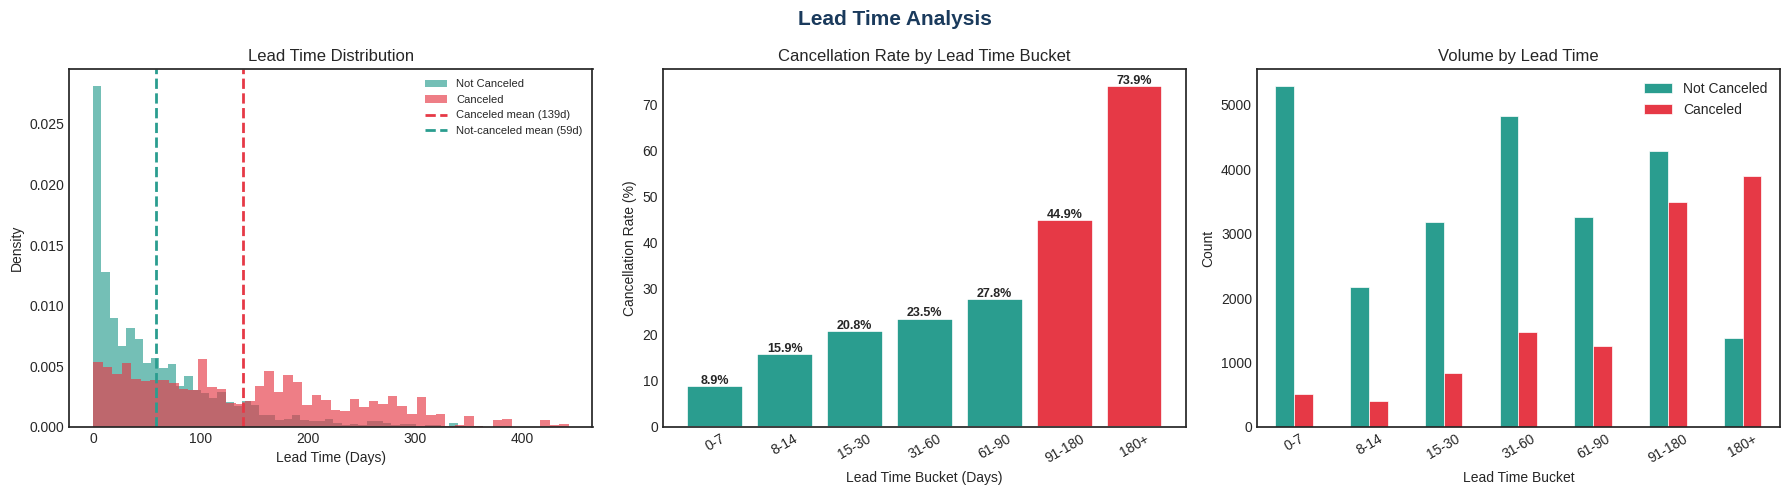

  Canceled avg lead time    : 139.2 days
  Not-Canceled avg lead time: 58.9 days
  Bookings >90 days ahead have significantly higher cancellation rates.


In [49]:
canceled     = df[df['booking_status'] == 'Canceled']['lead_time']
not_canceled = df[df['booking_status'] == 'Not_Canceled']['lead_time']

bins   = [0, 7, 14, 30, 60, 90, 180, 443]
labels = ['0-7','8-14','15-30','31-60','61-90','91-180','180+']
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=bins,
                              labels=labels, include_lowest=True)

lt_grp = (df.groupby(['lead_time_bin','booking_status'], observed=True)
          .size().unstack(fill_value=0))
lt_grp['cancel_rate'] = (lt_grp['Canceled'] /
    (lt_grp['Canceled'] + lt_grp['Not_Canceled']) * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Lead Time Analysis',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

axes[0].hist(not_canceled, bins=50, alpha=0.65, color=NO_CANCEL_COLOR,
             label='Not Canceled', density=True)
axes[0].hist(canceled, bins=50, alpha=0.65, color=CANCEL_COLOR,
             label='Canceled', density=True)
axes[0].axvline(canceled.mean(), color=CANCEL_COLOR, linestyle='--', linewidth=2,
                label=f'Canceled mean ({canceled.mean():.0f}d)')
axes[0].axvline(not_canceled.mean(), color=NO_CANCEL_COLOR, linestyle='--', linewidth=2,
                label=f'Not-canceled mean ({not_canceled.mean():.0f}d)')
axes[0].set_title('Lead Time Distribution')
axes[0].set_xlabel('Lead Time (Days)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

colors_bar = [CANCEL_COLOR if r > 40 else PALETTE['accent'] if r > 30
              else NO_CANCEL_COLOR for r in lt_grp['cancel_rate']]
axes[1].bar(lt_grp.index, lt_grp['cancel_rate'], color=colors_bar,
            edgecolor='white', linewidth=1.2)
for i, (_, row) in enumerate(lt_grp.iterrows()):
    axes[1].text(i, row['cancel_rate'] + 0.5, f"{row['cancel_rate']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Cancellation Rate by Lead Time Bucket')
axes[1].set_xlabel('Lead Time Bucket (Days)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

lt_grp[['Not_Canceled','Canceled']].plot(
    kind='bar', ax=axes[2],
    color=[NO_CANCEL_COLOR, CANCEL_COLOR], edgecolor='white', linewidth=0.5)
axes[2].set_title('Volume by Lead Time')
axes[2].set_xlabel('Lead Time Bucket')
axes[2].set_ylabel('Count')
axes[2].legend(['Not Canceled','Canceled'])
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_03_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Canceled avg lead time    : {canceled.mean():.1f} days')
print(f'  Not-Canceled avg lead time: {not_canceled.mean():.1f} days')
print('  Bookings >90 days ahead have significantly higher cancellation rates.')


# **📈 c. Market Segment & Room Type**

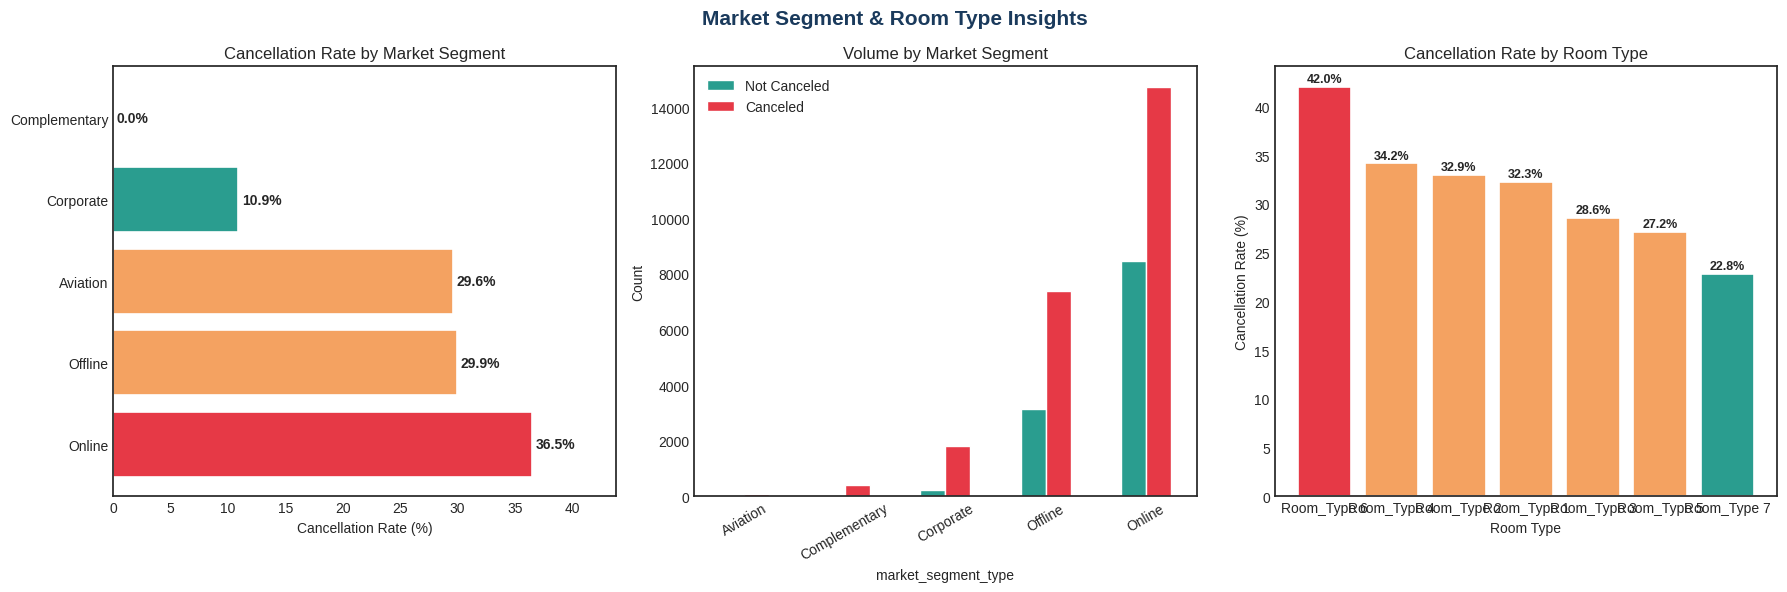

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Market Segment & Room Type Insights',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

mkt = (df.groupby('market_segment_type')['booking_status']
       .apply(lambda x: (x == 'Canceled').mean() * 100, include_groups=False)
       .sort_values(ascending=False))
bar_c = [CANCEL_COLOR if v > 30 else PALETTE['accent'] if v > 15
         else NO_CANCEL_COLOR for v in mkt.values]
axes[0].barh(mkt.index, mkt.values, color=bar_c, edgecolor='white', linewidth=1.2)
for i, v in enumerate(mkt.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Cancellation Rate by Market Segment')
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].set_xlim(0, mkt.max() * 1.2)

mkt_vol = (df.groupby(['market_segment_type','booking_status'])
           .size().unstack(fill_value=0))
mkt_vol.plot(kind='bar', ax=axes[1],
             color=[NO_CANCEL_COLOR, CANCEL_COLOR], edgecolor='white')
axes[1].set_title('Volume by Market Segment')
axes[1].set_ylabel('Count')
axes[1].legend(['Not Canceled','Canceled'])
axes[1].tick_params(axis='x', rotation=30)

room = (df.groupby('room_type_reserved')['booking_status']
        .apply(lambda x: (x == 'Canceled').mean() * 100, include_groups=False)
        .sort_values(ascending=False))
bar_r = [CANCEL_COLOR if v > 40 else PALETTE['accent'] if v > 25
         else NO_CANCEL_COLOR for v in room.values]
axes[2].bar(room.index, room.values, color=bar_r, edgecolor='white', linewidth=1.2)
for i, v in enumerate(room.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Cancellation Rate by Room Type')
axes[2].set_xlabel('Room Type')
axes[2].set_ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.savefig('fig_04_segment_room.png', dpi=150, bbox_inches='tight')
plt.show()


# **📊 d. Loyalty, Special Requests & Pricing**

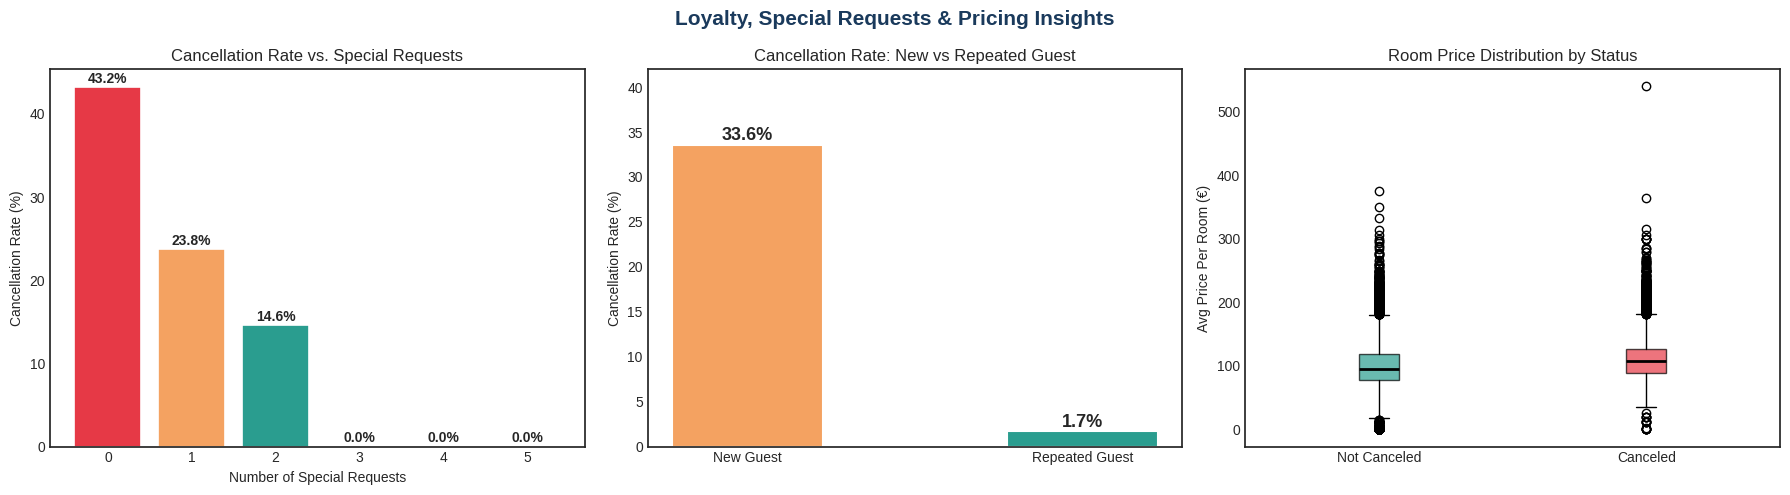

  Repeated guests cancel 1.7% vs 33.6% for new guests.
  Zero special requests → 43.2% cancellation rate.


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Loyalty, Special Requests & Pricing Insights',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

sr = (df.groupby('no_of_special_requests')['booking_status']
      .apply(lambda x: (x == 'Canceled').mean() * 100, include_groups=False))
axes[0].bar(sr.index.astype(str), sr.values,
            color=[CANCEL_COLOR if v > 30 else PALETTE['accent'] if v > 15
                   else NO_CANCEL_COLOR for v in sr.values],
            edgecolor='white', linewidth=1.2)
for i, v in enumerate(sr.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Cancellation Rate vs. Special Requests')
axes[0].set_xlabel('Number of Special Requests')
axes[0].set_ylabel('Cancellation Rate (%)')

rg = (df.groupby('repeated_guest')['booking_status']
      .apply(lambda x: (x == 'Canceled').mean() * 100, include_groups=False))
bar_rg = axes[1].bar(['New Guest','Repeated Guest'], rg.values,
                     color=[PALETTE['accent'], NO_CANCEL_COLOR],
                     width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bar_rg, rg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
                 ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('Cancellation Rate: New vs Repeated Guest')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_ylim(0, max(rg.values) * 1.25)

c_p  = df[df['booking_status'] == 'Canceled']['avg_price_per_room']
nc_p = df[df['booking_status'] == 'Not_Canceled']['avg_price_per_room']
bp = axes[2].boxplot([nc_p, c_p], labels=['Not Canceled','Canceled'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor(NO_CANCEL_COLOR); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(CANCEL_COLOR);    bp['boxes'][1].set_alpha(0.7)
for mp in bp['medians']: mp.set_color('black'); mp.set_linewidth(2)
axes[2].set_title('Room Price Distribution by Status')
axes[2].set_ylabel('Avg Price Per Room (€)')

plt.tight_layout()
plt.savefig('fig_05_loyalty_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Repeated guests cancel {rg[1]:.1f}% vs {rg[0]:.1f}% for new guests.')
print(f'  Zero special requests → {sr[0]:.1f}% cancellation rate.')


# **📊 e. Feature Correlation Heatmap**

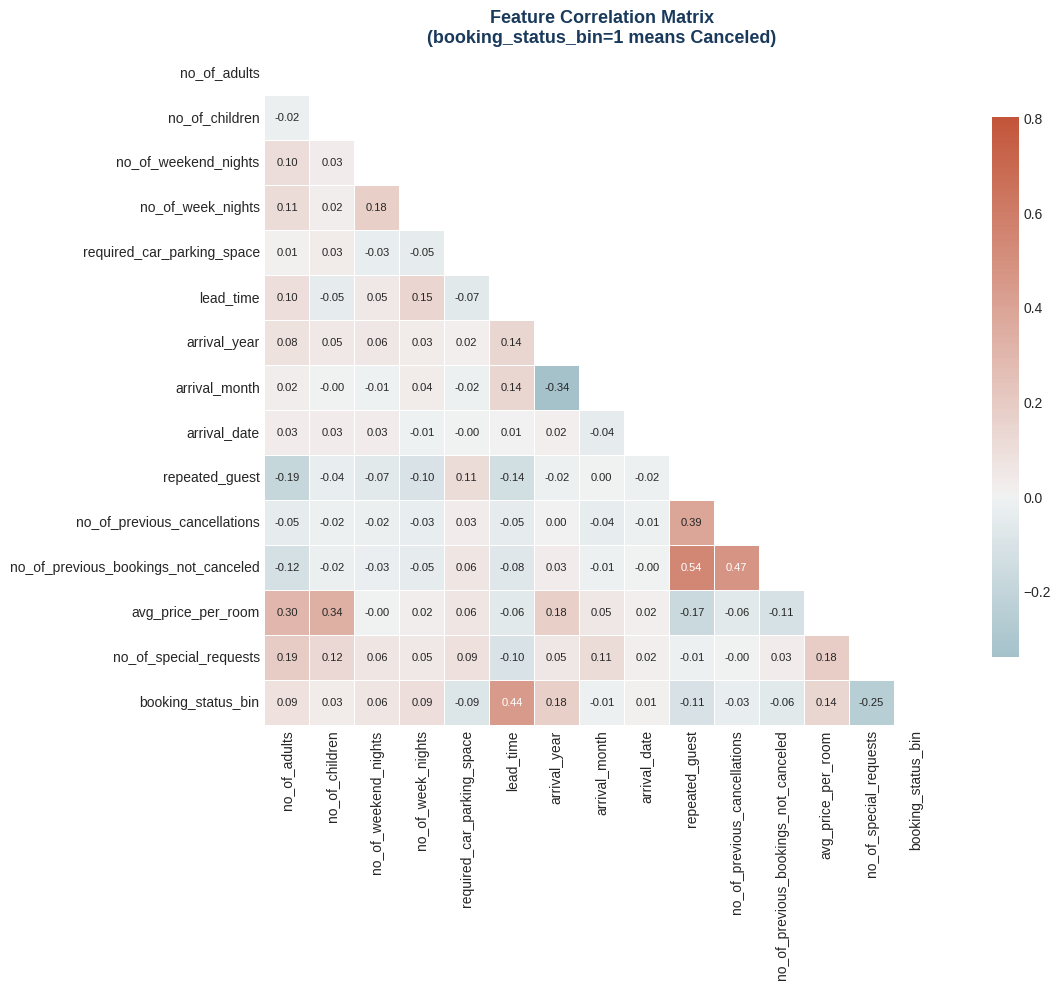


Top 10 features correlated with cancellation:
lead_time                               0.438538
no_of_special_requests                  0.253070
arrival_year                            0.179529
avg_price_per_room                      0.142569
repeated_guest                          0.107287
no_of_week_nights                       0.092996
no_of_adults                            0.086920
required_car_parking_space              0.086185
no_of_weekend_nights                    0.061563
no_of_previous_bookings_not_canceled    0.060179


In [52]:
df_num = df.copy()
df_num['booking_status_bin'] = (df_num['booking_status'] == 'Canceled').astype(int)
# Drop engineered & non-numeric before correlation
df_num = df_num.drop(columns=['lead_time_bin', 'booking_status', 'Booking_ID'], errors='ignore')
df_num = df_num.select_dtypes(include=[np.number])
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 20, as_cmap=True),
            vmax=0.8, center=0, square=True, linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix\n(booking_status_bin=1 means Canceled)',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('fig_06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = (corr['booking_status_bin'].drop('booking_status_bin')
               .abs().sort_values(ascending=False))
print('\nTop 10 features correlated with cancellation:')
print(target_corr.head(10).to_string())


# **🤖 Model Training**

In [30]:
# ── FIX #1: Drop EDA-only engineered feature before any split
# lead_time_bin is derived from lead_time — keeping it = leakage
X = df.drop(columns=['booking_status', 'Booking_ID', 'lead_time_bin'], errors='ignore')
y = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

# ── Train / Test Split (stratified, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train cancellation rate: {y_train.mean():.3f}')
print(f'Test  cancellation rate: {y_test.mean():.3f}')

# ── FIX #1 continued: Fit preprocessor on TRAIN only
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)
preprocessor.set_output(transform='pandas')

X_train_en = preprocessor.fit_transform(X_train)   # fit on TRAIN only
X_test_en  = preprocessor.transform(X_test)         # transform test (no fitting)
print(f'\nEncoded features: {X_train_en.shape[1]}')
print('✅ Preprocessor fitted on training data only — no leakage from test set.')

# ── Scaling — fit on TRAIN only
scaler   = StandardScaler()
X_tr_raw = scaler.fit_transform(X_train_en)   # fit on TRAIN only
X_te_raw = scaler.transform(X_test_en)         # transform test (no fitting)
print('✅ Scaler fitted on training data only.')

# ── FIX #2: SMOTETomek on TRAIN only (never on test)
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_tr, y_tr = smote_tomek.fit_resample(X_tr_raw, y_train)
X_te = X_te_raw  # test set stays untouched — real-world distribution

print(f'\nBefore SMOTETomek — Train: {X_tr_raw.shape[0]} samples')
print(f'After  SMOTETomek — Train: {X_tr.shape[0]} samples')
print(f'Resampled class balance: {pd.Series(y_tr).value_counts().to_dict()}')
print('✅ SMOTETomek applied on training set only — test distribution preserved.')


Features shape: (36275, 17)
Target distribution:
booking_status
0    24390
1    11885
Name: count, dtype: int64

Train size: 29020 | Test size: 7255
Train cancellation rate: 0.328
Test  cancellation rate: 0.328

Encoded features: 30
✅ Preprocessor fitted on training data only — no leakage from test set.
✅ Scaler fitted on training data only.

Before SMOTETomek — Train: 29020 samples
After  SMOTETomek — Train: 38000 samples
Resampled class balance: {0: 19000, 1: 19000}
✅ SMOTETomek applied on training set only — test distribution preserved.


In [31]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1, random_state=RANDOM_STATE),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                       max_depth=5, subsample=0.8,
                                                       random_state=RANDOM_STATE),
    'XGBoost'            : XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                         subsample=0.8, colsample_bytree=0.8,
                                         random_state=RANDOM_STATE, eval_metric='logloss',
                                         n_jobs=-1),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

results = {}
print(f"\n  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print('  ' + '-' * 70)

for name, model in baseline_models.items():
    model.fit(X_tr, y_tr)  # Train on SMOTE-resampled data
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'AUC'      : roc_auc_score(y_test, y_prob),
        'pred'     : y_pred,
        'prob'     : y_prob,
    }
    results[name] = metrics
    print(f"  {name:<22} {metrics['Accuracy']:>9.4f} {metrics['Precision']:>10.4f} "
          f"{metrics['Recall']:>8.4f} {metrics['F1']:>8.4f} {metrics['AUC']:>8.4f}")



  Model                   Accuracy  Precision   Recall       F1      AUC
  ----------------------------------------------------------------------
  Logistic Regression       0.7862     0.6446   0.7745   0.7036   0.8712
  Decision Tree             0.8622     0.7703   0.8254   0.7969   0.9292
  Random Forest             0.9021     0.8591   0.8389   0.8489   0.9558
  Gradient Boosting         0.8848     0.8305   0.8145   0.8224   0.9460
  XGBoost                   0.8805     0.8175   0.8178   0.8177   0.9448
  AdaBoost                  0.7989     0.6559   0.8124   0.7258   0.8783


# **🔲 Confusion Matrix (All Models)**

In [32]:
# Confusion Matrices for first 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, vals) in zip(axes, list(results.items())[:3]):
    cm = confusion_matrix(y_test, vals['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Cancelled', 'Cancelled'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc: {vals["Accuracy"]:.4f}', fontsize=11, fontweight='bold')

# FIX #3: Correct title (was 'Fatal Shooting' — copy-paste error)
plt.suptitle('Confusion Matrices — Hotel Booking Cancellation Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()



# **📈 ROC-AUC Curve**

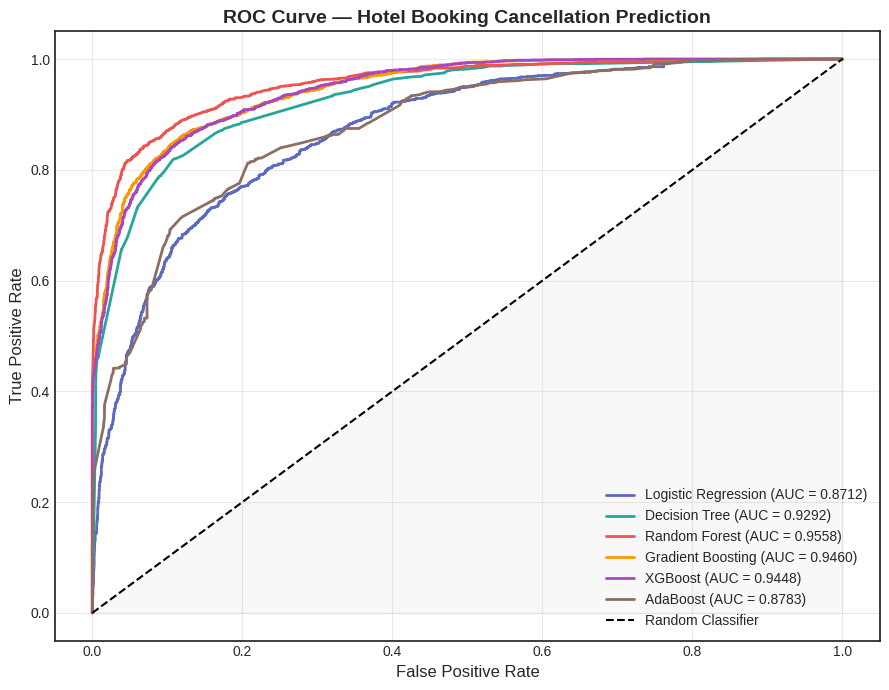

In [53]:


fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#5C6BC0', '#26A69A', '#EF5350', '#FF9800', '#AB47BC', '#8D6E63']

for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, vals['prob'])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {vals["AUC"]:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)

ax.set_title('ROC Curve — Hotel Booking Cancellation Prediction', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# **🔁 Cross-Validation (Overfitting / Underfitting Check)**

In [33]:
print('Cross-Validation Check (5-Fold, Stratified)\n')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model_obj in baseline_models.items():
    cv_scores = cross_val_score(
        model_obj, X_tr, y_tr,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    train_acc = accuracy_score(y_tr, model_obj.predict(X_tr))
    test_acc  = results[name]['Accuracy']

    cv_results[name] = {
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Gap (Train-Test)': train_acc - test_acc
    }
    print(f'{name}:')
    print(f'  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {train_acc - test_acc:.4f}')
    print(f'  CV Scores: {cv_scores.round(4)} | Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    if train_acc - test_acc > 0.05:
        print(f'  ⚠️  Possible overfitting — consider stronger regularization.')
    elif test_acc < 0.75:
        print(f'  ⚠️  Possible underfitting — consider more features.')
    else:
        print(f'  ✅ Good generalization!')
    print()


Cross-Validation Check (5-Fold, Stratified)

Logistic Regression:
  Train Acc: 0.7849 | Test Acc: 0.7862 | Gap: -0.0013
  CV Scores: [0.7861 0.7904 0.7793 0.7841 0.7813] | Mean: 0.7842 ± 0.0038
  ✅ Good generalization!

Decision Tree:
  Train Acc: 0.8796 | Test Acc: 0.8622 | Gap: 0.0175
  CV Scores: [0.8646 0.8699 0.8762 0.8755 0.8667] | Mean: 0.8706 ± 0.0046
  ✅ Good generalization!

Random Forest:
  Train Acc: 0.9950 | Test Acc: 0.9021 | Gap: 0.0928
  CV Scores: [0.935  0.9325 0.9299 0.9325 0.9312] | Mean: 0.9322 ± 0.0017
  ⚠️  Possible overfitting — consider stronger regularization.

Gradient Boosting:
  Train Acc: 0.9162 | Test Acc: 0.8848 | Gap: 0.0314
  CV Scores: [0.9039 0.9107 0.9032 0.9025 0.9091] | Mean: 0.9059 ± 0.0033
  ✅ Good generalization!

XGBoost:
  Train Acc: 0.9030 | Test Acc: 0.8805 | Gap: 0.0225
  CV Scores: [0.8993 0.8997 0.8937 0.8959 0.9003] | Mean: 0.8978 ± 0.0026
  ✅ Good generalization!

AdaBoost:
  Train Acc: 0.8021 | Test Acc: 0.7989 | Gap: 0.0032
  CV Scor

# **⚙️ Hyperparameter Tuning (GridSearchCV)**


In [34]:
print('=' * 70)
print('  HYPERPARAMETER TUNING (GridSearchCV — training set only)')
print('=' * 70)

param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Random Forest': {
        'n_estimators': [300, 500],
        'max_depth': [10, 15, 20, None],
        'min_samples_leaf': [1, 2],
        'class_weight': ['balanced']
    },
    'Gradient Boosting': {
        'n_estimators': [200, 300],
        'learning_rate': [0.05, 0.1],
        'max_depth': [4, 5, 6],
        'subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators': [200, 300],
        'learning_rate': [0.05, 0.1],
        'max_depth': [4, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }
}

tuned_models = {}

for name, grid in param_grids.items():
    print(f'\n  Tuning {name}...')
    start_time = time.time()
    base_estimator = baseline_models[name]
    grid_search = GridSearchCV(
        estimator=base_estimator,
        param_grid=grid,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_tr, y_tr)
    tuned_models[name] = grid_search.best_estimator_
    elapsed = time.time() - start_time
    print(f'  ✅ Best params for {name}: {grid_search.best_params_}')
    print(f'  ✅ Best CV AUC: {grid_search.best_score_:.4f}')
    print(f'  ⏱️  Time: {elapsed:.2f}s')


  HYPERPARAMETER TUNING (GridSearchCV — training set only)

  Tuning Logistic Regression...
  ✅ Best params for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  ✅ Best CV AUC: 0.8703
  ⏱️  Time: 2.28s

  Tuning Random Forest...
  ✅ Best params for Random Forest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500}
  ✅ Best CV AUC: 0.9812
  ⏱️  Time: 1030.49s

  Tuning Gradient Boosting...
  ✅ Best params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
  ✅ Best CV AUC: 0.9792
  ⏱️  Time: 2436.93s

  Tuning XGBoost...
  ✅ Best params for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
  ✅ Best CV AUC: 0.9803
  ⏱️  Time: 385.45s


# **🔁 Cross-Validation (Accuracy, Precision, Recall, F1-Score)**

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

print('=' * 70)
print('       GRIDSEARCHCV INTERNAL EVALUATION (Out-of-Fold Predictions)')
print('=' * 70)

# We loop through the best estimators found by GridSearchCV
for name, model in tuned_models.items():
    print(f"\n" + "-"*50)
    print(f"🔄 Generating Cross-Validated Predictions for {name}...")
    print("-"*50)

    # 1. Get Out-of-Fold (OOF) predictions using the exact same CV split (skf)
    # This mimics how GridSearchCV evaluated the models internally
    try:
        y_cv_prob = cross_val_predict(model, X_tr, y_tr, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
        y_cv_pred = cross_val_predict(model, X_tr, y_tr, cv=skf, method='predict', n_jobs=-1)
    except AttributeError:
        # Fallback for models without predict_proba
        y_cv_prob = cross_val_predict(model, X_tr, y_tr, cv=skf, method='decision_function', n_jobs=-1)
        y_cv_pred = cross_val_predict(model, X_tr, y_tr, cv=skf, method='predict', n_jobs=-1)

    # 2. Print Classification Report based on CV results fjlsdfklhfglkjdfhghndfjghdfsdfasdfsafkpi-i
    print(classification_report(y_tr, y_cv_pred))

    # 3. Setup Plotting Canvas (Side-by-Side)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: CV Confusion Matrix ---
    cm = confusion_matrix(y_tr, y_cv_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[0].set_title(f'{name} - GridSearch CV Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # --- Plot 2: CV ROC Curve ---
    fpr, tpr, _ = roc_curve(y_tr, y_cv_prob)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'CV ROC Curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - GridSearch CV ROC Curve')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

       GRIDSEARCHCV INTERNAL EVALUATION (Out-of-Fold Predictions)

--------------------------------------------------
🔄 Generating Cross-Validated Predictions for Logistic Regression...
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.79      0.79     19000
           1       0.79      0.78      0.78     19000

    accuracy                           0.78     38000
   macro avg       0.78      0.78      0.78     38000
weighted avg       0.78      0.78      0.78     38000


--------------------------------------------------
🔄 Generating Cross-Validated Predictions for Random Forest...
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     19000
           1       0.94      0.93      0.93     19000

    accuracy                           0.93     38000
   macro avg       0.93      0.93      0.93     38000

# **Leakage & Validation Audit**

In [54]:



print('=' * 70)
print('🔍 LEAKAGE & VALIDATION CHECK (Updated for Tuned Models)')
print('=' * 70)

# 1. Preprocessing confirmation
print('✅ Preprocessor & Scaler were fit only on X_train — test set was never seen during fit.')

# 2. Check for duplicate rows between train and test
dup_count = pd.merge(X_train.reset_index(drop=True),
                     X_test.reset_index(drop=True), how='inner').shape[0]
print(f'✅ Duplicate rows shared between Train & Test: {dup_count}')
if dup_count == 0:
    print('   -> No exact duplicate rows between train and test sets.')
else:
    print(f'⚠️   {dup_count} exact duplicate rows found — review data splits.')

# 3. Feature correlation with target (train only)
leak_check = pd.DataFrame(X_tr, columns=X_train_en.columns).copy()
leak_check['target'] = y_tr.values
target_corr_check = leak_check.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('\nTop 5 feature correlations with target (train set):')
print(target_corr_check.head(5).to_string())

suspicious = target_corr_check[target_corr_check > 0.90]
if len(suspicious) > 0:
    print(f'\n⚠️  Possible leakage — suspiciously high correlation: {suspicious.index.tolist()}')
else:
    print('\n✅ No feature shows suspiciously high correlation (>0.90) with target — no leakage.')

# 4. Overfitting check calibrated to your GridSearchCV metric (ROC-AUC)
print('\n' + '-'*50)
print('📈 OVERFITTING CHECK (Train AUC vs. GridSearchCV Best CV Score)')
print('-'*50)

for name, model in tuned_models.items():
    # Calculate Train AUC
    if hasattr(model, "predict_proba"):
        y_tr_prob = model.predict_proba(X_tr)[:, 1]
    else:
        y_tr_prob = model.decision_function(X_tr)

    train_auc = roc_auc_score(y_tr, y_tr_prob)

    # Grab the best CV score directly from your grid search loop's output history
    # Or calculate it fresh using cross_val_score to match your 'roc_auc' optimization
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_auc_mean = cv_scores.mean()

    gap_auc = train_auc - cv_auc_mean

    print(f'\n▶️ {name} (Tuned):')
    print(f'   Train ROC-AUC: {train_auc:.4f} | CV ROC-AUC Mean: {cv_auc_mean:.4f} | Gap: {gap_auc:.4f}')
    print(f'   CV Scores Std Dev: ±{cv_scores.std():.4f}')

    if gap_auc <= 0.05:
        print('   ✅ Excellent generalization! Low variance between training and CV folds.')
    elif gap_auc <= 0.10:
        print('   ⚠️  Acceptable generalization, but slight overfitting observed.')
    else:
        print('   🚨 High Variance! The model is significantly overfitting the training subset.')

🔍 LEAKAGE & VALIDATION CHECK (Updated for Tuned Models)
✅ Preprocessor & Scaler were fit only on X_train — test set was never seen during fit.
✅ Duplicate rows shared between Train & Test: 33881
⚠️   33881 exact duplicate rows found — review data splits.

Top 5 feature correlations with target (train set):
remainder__lead_time                  0.439565
remainder__no_of_special_requests     0.289590
remainder__arrival_year               0.213252
remainder__avg_price_per_room         0.162590
cat__market_segment_type_Corporate    0.136592

✅ No feature shows suspiciously high correlation (>0.90) with target — no leakage.

--------------------------------------------------
📈 OVERFITTING CHECK (Train AUC vs. GridSearchCV Best CV Score)
--------------------------------------------------

▶️ Logistic Regression (Tuned):
   Train ROC-AUC: 0.8706 | CV ROC-AUC Mean: 0.8703 | Gap: 0.0004
   CV Scores Std Dev: ±0.0040
   ✅ Excellent generalization! Low variance between training and CV folds.

▶️ 

In [55]:
print('Leakage & Validation Check\n')

# 1. Preprocessing was fit ONLY on training data
print('✅ Preprocessor & Scaler were fit only on X_train — test set was never seen during fit.')

# 2. Check for duplicate rows between train and test
dup_count = pd.merge(X_train.reset_index(drop=True),
                     X_test.reset_index(drop=True), how='inner').shape[0]
print(f'Duplicate rows shared between Train & Test: {dup_count}')
if dup_count == 0:
    print('✅ No exact duplicate rows between train and test sets.')
else:
    print(f'⚠️  {dup_count} exact duplicate rows found — review data.')

# 3. Feature correlation with target (train only)
leak_check = pd.DataFrame(X_tr, columns=X_train_en.columns).copy()
leak_check['target'] = y_tr.values
target_corr_check = leak_check.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('\nTop 5 feature correlations with target (train set):')
print(target_corr_check.head(5).to_string())

suspicious = target_corr_check[target_corr_check > 0.90]
if len(suspicious) > 0:
    print(f'\n⚠️  Possible leakage — suspiciously high correlation: {suspicious.index.tolist()}')
else:
    print('\n✅ No feature shows suspiciously high correlation (>0.90) with target — no leakage.')

# 4. Overfitting check for Random Forest
rf_final     = tuned_models['Random Forest']
cv_scores_rf = cross_val_score(rf_final, X_tr, y_tr, cv=skf, scoring='accuracy', n_jobs=-1)
train_acc_rf = accuracy_score(y_tr, rf_final.predict(X_tr))
test_acc_rf  = results['Random Forest']['Accuracy']
gap_rf       = train_acc_rf - test_acc_rf
print(f'\nRandom Forest (tuned) → Train Acc: {train_acc_rf:.4f} | Test Acc: {test_acc_rf:.4f} | Gap: {gap_rf:.4f}')
print(f'CV Scores Mean: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print('✅ Good generalization!' if gap_rf <= 0.05 else '⚠️  Consider stronger constraints.')


Leakage & Validation Check

✅ Preprocessor & Scaler were fit only on X_train — test set was never seen during fit.
Duplicate rows shared between Train & Test: 33881
⚠️  33881 exact duplicate rows found — review data.

Top 5 feature correlations with target (train set):
remainder__lead_time                  0.439565
remainder__no_of_special_requests     0.289590
remainder__arrival_year               0.213252
remainder__avg_price_per_room         0.162590
cat__market_segment_type_Corporate    0.136592

✅ No feature shows suspiciously high correlation (>0.90) with target — no leakage.

Random Forest (tuned) → Train Acc: 0.9950 | Test Acc: 0.9021 | Gap: 0.0928
CV Scores Mean: 0.9322 ± 0.0017
⚠️  Consider stronger constraints.


# **📈SHAP Explainability**

Generating SHAP explanations for the tuned Random Forest model...



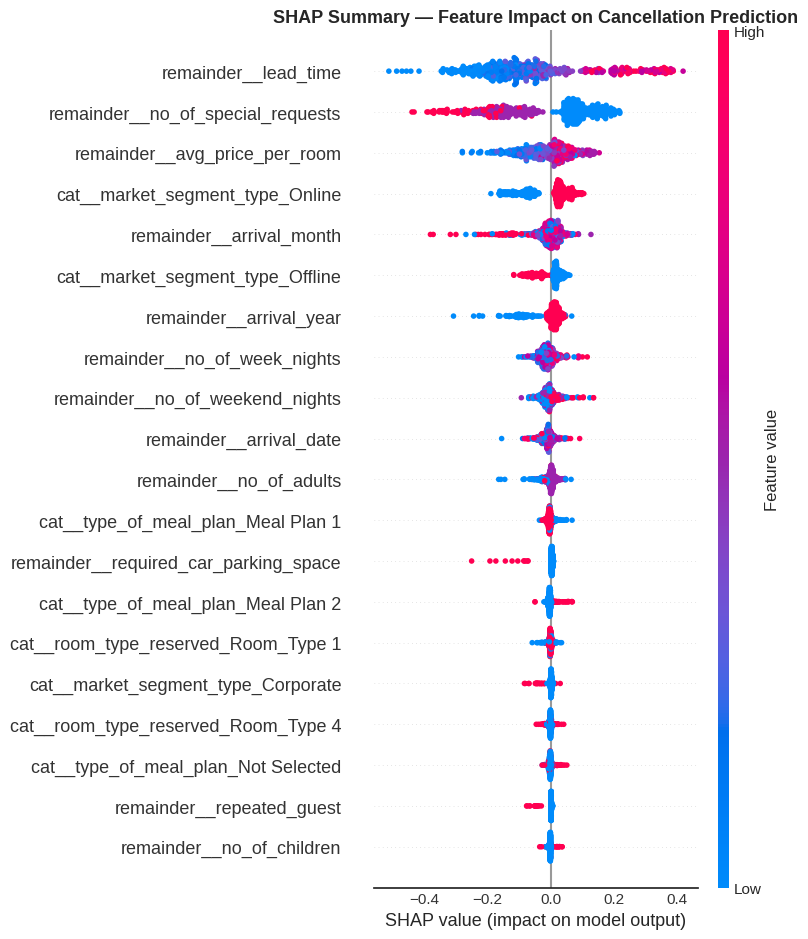

Features furthest from zero (red = push toward Cancellation) are most influential.


In [56]:
print('Generating SHAP explanations for the tuned Random Forest model...\n')

explainer = shap.TreeExplainer(tuned_models['Random Forest'])

rng = np.random.RandomState(42)
sample_idx = rng.choice(X_te.shape[0], size=min(500, X_te.shape[0]), replace=False)
X_sample = X_te[sample_idx]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

feature_names = X_train_en.columns.tolist()

plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary — Feature Impact on Cancellation Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_shap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features furthest from zero (red = push toward Cancellation) are most influential.')

# **✅Reservation Prediction System**



In [57]:
def predict_custom_reservation():
    print('\nEnter hotel reservation details to predict cancellation:\n')
    try:
        # 1. Gather numerical and basic inputs
        lead_time                            = float(input('Lead Time (days between booking and arrival): '))
        no_of_special_requests             = int(input('Number of Special Requests (0-5): '))
        avg_price_per_room                 = float(input('Average Price per Room (€): '))
        arrival_year                       = int(input('Arrival Year (e.g., 2017, 2018): '))
        arrival_month                      = int(input('Arrival Month (1-12): '))
        arrival_date                       = int(input('Arrival Date (1-31): '))
        no_of_week_nights                  = int(input('Number of Week Nights: '))
        no_of_weekend_nights               = int(input('Number of Weekend Nights: '))
        no_of_adults                       = int(input('Number of Adults: '))
        no_of_children                     = int(input('Number of Children: '))
        repeated_guest                     = int(input('Repeated Guest? (1=Yes, 0=No): '))
        no_of_previous_cancellations       = int(input('Number of Previous Cancellations (1=Yes, 0=No): '))
        no_of_previous_bookings_not_canceled = int(input('Number of Previous Bookings NOT Canceled (1=Yes, 0=No): '))

        print('\n--- Categorical Options ---')

        # Meal Plan mapping
        print('Meal Plans: [1] Meal Plan 1, [2] Meal Plan 2, [3] Meal Plan 3, [ns] Not Selected')
        type_of_meal_plan_raw = input('Enter Meal Plan: ').strip().lower()
        meal_map = {'1': 'Meal Plan 1', '2': 'Meal Plan 2', '3': 'Meal Plan 3', 'ns': 'Not Selected', '': 'Not Selected'}
        if type_of_meal_plan_raw not in meal_map:
            print('🚨 Invalid input. Please enter 1, 2, 3, or ns')
            return
        type_of_meal_plan = meal_map[type_of_meal_plan_raw]

        # Room Type mapping
        print('Room Types: [1] Room_Type 1  [2] Room_Type 2 ... [7] Room_Type 7')
        room_type_reserved_raw = input('Enter Room Type (1-7): ').strip()
        room_map = {str(i): f'Room_Type {i}' for i in range(1, 8)}
        if room_type_reserved_raw not in room_map:
            print('🚨 Invalid input. Please enter 1-7')
            return
        room_type_reserved = room_map[room_type_reserved_raw]

        # Market Segment input
        print('Market Segments: Offline / Online / Corporate / Aviation / Complementary')
        market_segment_type = input('Enter Market Segment Type: ').strip()

        # 2. Extract Random Forest model directly from your tuned_models dictionary
        if 'Random Forest' not in tuned_models:
            print("🚨 Error: 'Random Forest' not found in tuned_models dictionary. Please run your tuning loop first.")
            return
        model = tuned_models['Random Forest']

        # 3. Structure into DataFrame matching your exact pipeline columns
        custom_data = {
            'no_of_adults'                         : [no_of_adults],
            'no_of_children'                       : [no_of_children],
            'no_of_weekend_nights'                 : [no_of_weekend_nights],
            'no_of_week_nights'                    : [no_of_week_nights],
            'type_of_meal_plan'                    : [type_of_meal_plan],
            'required_car_parking_space'           : [0],
            'room_type_reserved'                   : [room_type_reserved],
            'lead_time'                            : [lead_time],
            'arrival_year'                         : [arrival_year],
            'arrival_month'                        : [arrival_month],
            'arrival_date'                         : [arrival_date],
            'market_segment_type'                  : [market_segment_type],
            'repeated_guest'                       : [repeated_guest],
            'no_of_previous_cancellations'         : [no_of_previous_cancellations],
            'no_of_previous_bookings_not_canceled': [no_of_previous_bookings_not_canceled],
            'avg_price_per_room'                   : [avg_price_per_room],
            'no_of_special_requests'               : [no_of_special_requests]
        }

        # Align columns to match the baseline feature ordering
        custom_df      = pd.DataFrame(custom_data)[X.columns]
        custom_encoded = preprocessor.transform(custom_df)
        custom_scaled  = scaler.transform(custom_encoded)

        # 4. Calculate probability using Random Forest
        prob = model.predict_proba(custom_scaled)[:, 1][0]

        # Fallback threshold checking if BEST_THRESHOLD is not globally defined yet
        threshold = BEST_THRESHOLD if 'BEST_THRESHOLD' in globals() else 0.5
        prediction = 1 if prob >= threshold else 0

        # 5. Output Prediction Report
        print('\n' + '-'*55)
        print('🔮 PREDICTION ANALYSIS REPORT (RANDOM FOREST)')
        print(f'  Cancellation Probability : {prob * 100:.2f}%')
        print(f'  Decision Threshold       : {threshold:.3f}')
        print('-'*55)
        if prediction == 1:
            print('🚨 RESULT: Model predicts this reservation WILL BE CANCELED.')
        else:
            print('✅ RESULT: Model predicts this reservation WILL NOT BE CANCELED.')
        print('-'*55)

    except Exception as e:
        print(f'\n❌ Error: {e}. Ensure values match expected types and categories.')



# **✒️User Input**

In [58]:

predict_custom_reservation()


Enter hotel reservation details to predict cancellation:

Lead Time (days between booking and arrival): 30
Number of Special Requests (0-5): 5
Average Price per Room (€): 1000000
Arrival Year (e.g., 2017, 2018): 2026
Arrival Month (1-12): 3
Arrival Date (1-31): 30
Number of Week Nights: 6
Number of Weekend Nights: 2
Number of Adults: 5
Number of Children: 0
Repeated Guest? (1=Yes, 0=No): 0
Number of Previous Cancellations (1=Yes, 0=No): 0
Number of Previous Bookings NOT Canceled (1=Yes, 0=No): 0

--- Categorical Options ---
Meal Plans: [1] Meal Plan 1, [2] Meal Plan 2, [3] Meal Plan 3, [ns] Not Selected
Enter Meal Plan: 1
Room Types: [1] Room_Type 1  [2] Room_Type 2 ... [7] Room_Type 7
Enter Room Type (1-7): 1
Market Segments: Offline / Online / Corporate / Aviation / Complementary
Enter Market Segment Type: Online 

-------------------------------------------------------
🔮 PREDICTION ANALYSIS REPORT (RANDOM FOREST)
  Cancellation Probability : 15.80%
  Decision Threshold       : 0.50